# Individual Factor Analysis

Train a model on **one feature at a time** and compare across several algorithms.
Goal: see how much signal each single feature carries in isolation, and which algorithm extracts it best.

CV scheme matches `training.ipynb` (StratifiedGroupKFold on `Race_Year_Driver`) so scores are comparable to the baseline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42
DATA_DIR = Path('.')

/home/propar/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Load data

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')

TARGET = 'PitNextLap'
ID_COL = 'id'
CAT_COLS = ['Driver', 'Compound', 'Race']
DROP_COLS = [ID_COL, TARGET, 'LapNumber']
FEATURES = [c for c in train.columns if c not in DROP_COLS]

for c in CAT_COLS:
    train[c] = train[c].astype('category')

y = train[TARGET]
groups = (train['Race'].astype(str) + '_' + train['Year'].astype(str) + '_' + train['Driver'].astype(str))

print(f'{len(FEATURES)} features, {len(train):,} rows')
FEATURES

13 features, 439,140 rows


['Driver',
 'Compound',
 'Race',
 'Year',
 'PitStop',
 'Stint',
 'TyreLife',
 'Position',
 'LapTime (s)',
 'LapTime_Delta',
 'Cumulative_Degradation',
 'RaceProgress',
 'Position_Change']

## 2. Per-feature, per-algorithm CV

For each feature, train each algorithm using only that single feature and report mean OOF AUC.
Categorical features are handled natively by LightGBM; for the sklearn models they're label-encoded via `cat.codes` and numeric columns are imputed + scaled (only matters for logistic regression).

In [3]:
N_SPLITS = 5
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

LGB_PARAMS = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'feature_fraction': 1.0,
    'bagging_fraction': 0.9,
    'bagging_freq': 5,
    'min_data_in_leaf': 100,
    'verbose': -1,
    'seed': RANDOM_STATE,
}

def prep_sklearn(col: pd.Series) -> np.ndarray:
    """Turn a single feature column into a 2D float array for sklearn models."""
    if str(col.dtype) == 'category':
        x = col.cat.codes.astype(float).to_numpy()
    else:
        x = col.astype(float).to_numpy()
        med = np.nanmedian(x)
        x = np.where(np.isnan(x), med, x)
    return x.reshape(-1, 1)

def cv_lightgbm(feat: str) -> float:
    X = train[[feat]]
    cats = [feat] if feat in CAT_COLS else 'auto'
    oof = np.zeros(len(train))
    for tr, va in cv.split(X, y, groups):
        dtr = lgb.Dataset(X.iloc[tr], y.iloc[tr], categorical_feature=cats)
        dva = lgb.Dataset(X.iloc[va], y.iloc[va], categorical_feature=cats)
        m = lgb.train(LGB_PARAMS, dtr, num_boost_round=1000,
                      valid_sets=[dva],
                      callbacks=[lgb.early_stopping(50, verbose=False)])
        oof[va] = m.predict(X.iloc[va])
    return roc_auc_score(y, oof)

def cv_sklearn(feat: str, model_factory) -> float:
    X = prep_sklearn(train[feat])
    oof = np.zeros(len(train))
    for tr, va in cv.split(X, y, groups):
        model = model_factory()
        # logistic regression benefits from scaling; trees don't care
        if isinstance(model, LogisticRegression):
            sc = StandardScaler()
            Xtr = sc.fit_transform(X[tr])
            Xva = sc.transform(X[va])
        else:
            Xtr, Xva = X[tr], X[va]
        model.fit(Xtr, y.iloc[tr])
        oof[va] = model.predict_proba(Xva)[:, 1]
    return roc_auc_score(y, oof)

ALGOS = {
    'LightGBM': cv_lightgbm,
    'LogReg': lambda f: cv_sklearn(f, lambda: LogisticRegression(max_iter=1000)),
    'DecisionTree': lambda f: cv_sklearn(f, lambda: DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)),
    'RandomForest': lambda f: cv_sklearn(f, lambda: RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=RANDOM_STATE)),
}

In [4]:
results = []
for feat in FEATURES:
    for name, fn in ALGOS.items():
        try:
            auc = fn(feat)
        except Exception as e:
            print(f'  {feat:25s} {name:13s} FAILED: {e}')
            auc = np.nan
        print(f'  {feat:25s} {name:13s} AUC={auc:.4f}')
        results.append({'feature': feat, 'algorithm': name, 'cv_auc': auc})

results_df = pd.DataFrame(results)
results_df

  Driver                    LightGBM      AUC=0.5551
  Driver                    LogReg        AUC=0.5130
  Driver                    DecisionTree  AUC=0.5688
  Driver                    RandomForest  AUC=0.5680
  Compound                  LightGBM      AUC=0.6725
  Compound                  LogReg        AUC=0.6462
  Compound                  DecisionTree  AUC=0.6715
  Compound                  RandomForest  AUC=0.6715
  Race                      LightGBM      AUC=0.6206
  Race                      LogReg        AUC=0.5020
  Race                      DecisionTree  AUC=0.6253
  Race                      RandomForest  AUC=0.6311
  Year                      LightGBM      AUC=0.6932
  Year                      LogReg        AUC=0.5949
  Year                      DecisionTree  AUC=0.6929
  Year                      RandomForest  AUC=0.6930
  PitStop                   LightGBM      AUC=0.5198
  PitStop                   LogReg        AUC=0.5195
  PitStop                   DecisionTree  AUC=

,feature,algorithm,cv_auc
0,Driver,LightGBM,0.555146
1,Driver,LogReg,0.513027
2,Driver,DecisionTree,0.568824
3,Driver,RandomForest,0.567961
4,Compound,LightGBM,0.672549
5,Compound,LogReg,0.646177
6,Compound,DecisionTree,0.671499
7,Compound,RandomForest,0.671499
8,Race,LightGBM,0.620579
9,Race,LogReg,0.502013


## 3. Results

In [5]:
pivot = results_df.pivot(index='feature', columns='algorithm', values='cv_auc')
pivot['best'] = pivot.max(axis=1)
pivot['best_algo'] = pivot.drop(columns='best').idxmax(axis=1)
pivot = pivot.sort_values('best', ascending=False)
pivot

algorithm,DecisionTree,LightGBM,LogReg,RandomForest,best,best_algo
feature,,,,,,
Stint,0.745599,0.746156,0.683406,0.745616,0.746156,LightGBM
RaceProgress,0.726789,0.736981,0.664358,0.743252,0.743252,RandomForest
LapTime_Delta,0.704045,0.711822,0.544119,0.713788,0.713788,RandomForest
TyreLife,0.698531,0.690804,0.698910,0.698612,0.698910,LogReg
Year,0.692911,0.693153,0.594924,0.692959,0.693153,LightGBM
Cumulative_Degradation,0.673332,0.681406,0.611088,0.685044,0.685044,RandomForest
Position_Change,0.678181,0.672467,0.527403,0.678322,0.678322,RandomForest
Compound,0.671499,0.672549,0.646177,0.671499,0.672549,LightGBM
Race,0.625317,0.620579,0.502013,0.631106,0.631106,RandomForest


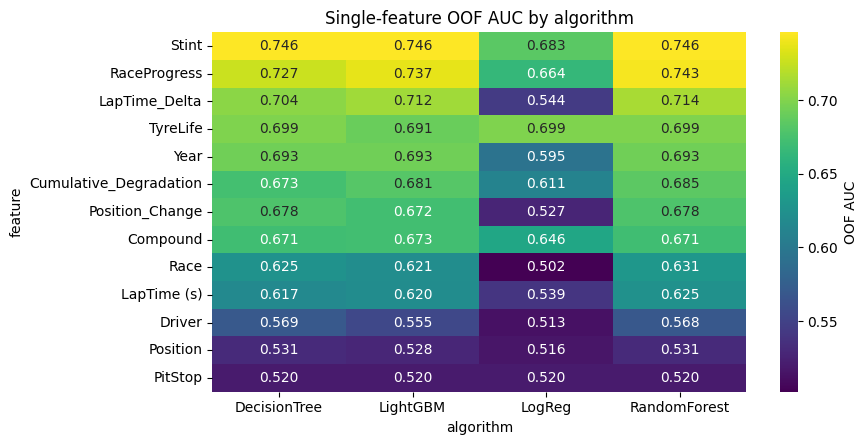

In [6]:
plt.figure(figsize=(9, max(4, len(FEATURES) * 0.35)))
sns.heatmap(pivot.drop(columns=['best', 'best_algo']), annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'OOF AUC'})
plt.title('Single-feature OOF AUC by algorithm')
plt.tight_layout(); plt.show()

## 4. All pairs of two features

Same CV scheme, same four algorithms — but now each model is trained on **two columns at a time**.
With 13 features that's C(13, 2) = 78 pairs × 4 algos = **312 CV runs**. RandomForest dominates the wall-clock.

In [7]:
from itertools import combinations

def prep_sklearn_multi(df: pd.DataFrame) -> np.ndarray:
    """Stack multiple feature columns into a 2D float array for sklearn models."""
    cols = []
    for c in df.columns:
        s = df[c]
        if str(s.dtype) == 'category':
            x = s.cat.codes.astype(float).to_numpy()
        else:
            x = s.astype(float).to_numpy()
            med = np.nanmedian(x)
            x = np.where(np.isnan(x), med, x)
        cols.append(x)
    return np.stack(cols, axis=1)

def cv_lightgbm_multi(feats):
    X = train[list(feats)]
    cats = [c for c in feats if c in CAT_COLS] or 'auto'
    oof = np.zeros(len(train))
    for tr, va in cv.split(X, y, groups):
        dtr = lgb.Dataset(X.iloc[tr], y.iloc[tr], categorical_feature=cats)
        dva = lgb.Dataset(X.iloc[va], y.iloc[va], categorical_feature=cats)
        m = lgb.train(LGB_PARAMS, dtr, num_boost_round=1000,
                      valid_sets=[dva],
                      callbacks=[lgb.early_stopping(50, verbose=False)])
        oof[va] = m.predict(X.iloc[va])
    return roc_auc_score(y, oof)

def cv_sklearn_multi(feats, model_factory):
    X = prep_sklearn_multi(train[list(feats)])
    oof = np.zeros(len(train))
    for tr, va in cv.split(X, y, groups):
        model = model_factory()
        if isinstance(model, LogisticRegression):
            sc = StandardScaler()
            Xtr = sc.fit_transform(X[tr])
            Xva = sc.transform(X[va])
        else:
            Xtr, Xva = X[tr], X[va]
        model.fit(Xtr, y.iloc[tr])
        oof[va] = model.predict_proba(Xva)[:, 1]
    return roc_auc_score(y, oof)

ALGOS_MULTI = {
    'LightGBM':     cv_lightgbm_multi,
    'LogReg':       lambda fs: cv_sklearn_multi(fs, lambda: LogisticRegression(max_iter=1000)),
    'DecisionTree': lambda fs: cv_sklearn_multi(fs, lambda: DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)),
    'RandomForest': lambda fs: cv_sklearn_multi(fs, lambda: RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=RANDOM_STATE)),
}

In [8]:
pair_results = []
pairs = list(combinations(FEATURES, 2))
print(f'Running {len(pairs)} pairs x {len(ALGOS_MULTI)} algos = {len(pairs) * len(ALGOS_MULTI)} CV runs')

for i, (f1, f2) in enumerate(pairs, 1):
    for name, fn in ALGOS_MULTI.items():
        try:
            auc = fn([f1, f2])
        except Exception as e:
            print(f'  [{i:3d}/{len(pairs)}] {f1} + {f2:25s} {name:13s} FAILED: {e}')
            auc = np.nan
        print(f'  [{i:3d}/{len(pairs)}] {f1:22s} + {f2:22s} {name:13s} AUC={auc:.4f}')
        pair_results.append({'f1': f1, 'f2': f2, 'algorithm': name, 'cv_auc': auc})

pair_df = pd.DataFrame(pair_results)
pair_df.to_csv('pair_results.csv', index=False)
pair_df

Running 78 pairs x 4 algos = 312 CV runs
  [  1/78] Driver                 + Compound               LightGBM      AUC=0.6834
  [  1/78] Driver                 + Compound               LogReg        AUC=0.6511
  [  1/78] Driver                 + Compound               DecisionTree  AUC=0.7051
  [  1/78] Driver                 + Compound               RandomForest  AUC=0.7075
  [  2/78] Driver                 + Race                   LightGBM      AUC=0.6008
  [  2/78] Driver                 + Race                   LogReg        AUC=0.5131
  [  2/78] Driver                 + Race                   DecisionTree  AUC=0.6080
  [  2/78] Driver                 + Race                   RandomForest  AUC=0.6348
  [  3/78] Driver                 + Year                   LightGBM      AUC=0.6925
  [  3/78] Driver                 + Year                   LogReg        AUC=0.5992
  [  3/78] Driver                 + Year                   DecisionTree  AUC=0.7074
  [  3/78] Driver                 +

,f1,f2,algorithm,cv_auc
0,Driver,Compound,LightGBM,0.683353
1,Driver,Compound,LogReg,0.651050
2,Driver,Compound,DecisionTree,0.705071
3,Driver,Compound,RandomForest,0.707458
4,Driver,Race,LightGBM,0.600829
...,...,...,...,...
307,Cumulative_Degradation,Position_Change,RandomForest,0.747769
308,RaceProgress,Position_Change,LightGBM,0.806770
309,RaceProgress,Position_Change,LogReg,0.661596
310,RaceProgress,Position_Change,DecisionTree,0.797783


### Top pairs and per-algorithm heatmap

In [9]:
pair_df['pair'] = pair_df['f1'] + ' + ' + pair_df['f2']
pair_pivot = pair_df.pivot(index='pair', columns='algorithm', values='cv_auc')
pair_pivot['best'] = pair_pivot.max(axis=1)
pair_pivot['best_algo'] = pair_pivot.drop(columns='best').idxmax(axis=1)
pair_pivot = pair_pivot.sort_values('best', ascending=False)
print('Top 15 pairs by best-algorithm AUC:')
pair_pivot.head(15)

Top 15 pairs by best-algorithm AUC:


algorithm,DecisionTree,LightGBM,LogReg,RandomForest,best,best_algo
pair,,,,,,
Year + Stint,0.859222,0.836058,0.690850,0.859240,0.859240,RandomForest
Stint + LapTime_Delta,0.838814,0.846691,0.696552,0.845132,0.846691,LightGBM
Year + RaceProgress,0.839945,0.843084,0.664773,0.842163,0.843084,LightGBM
TyreLife + RaceProgress,0.777157,0.833024,0.699607,0.809937,0.833024,LightGBM
LapTime_Delta + RaceProgress,0.815758,0.832676,0.664749,0.826323,0.832676,LightGBM
Compound + Year,0.829023,0.829268,0.688627,0.829025,0.829268,LightGBM
Year + TyreLife,0.828871,0.827809,0.702552,0.829112,0.829112,RandomForest
Stint + Position_Change,0.823385,0.814136,0.691449,0.824325,0.824325,RandomForest
Race + RaceProgress,0.743678,0.820655,0.664338,0.777780,0.820655,LightGBM


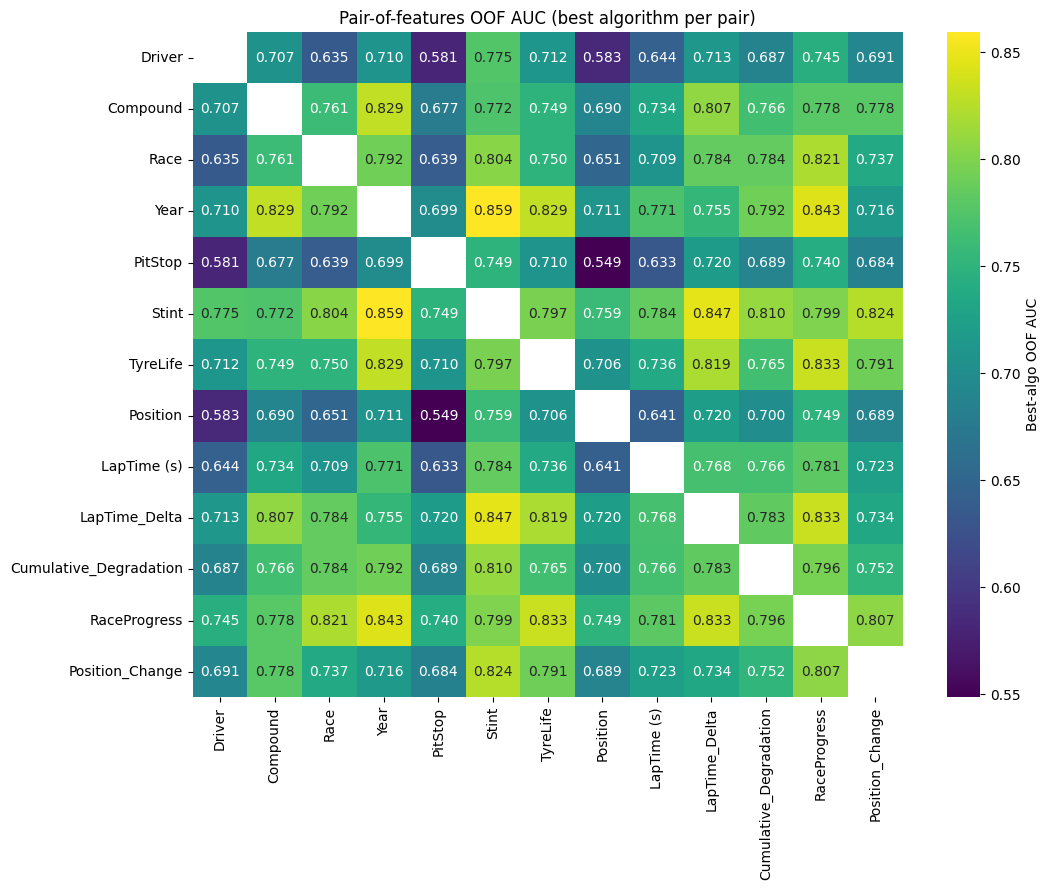

In [10]:
# Symmetric matrix of best-algo AUC per (f1, f2)
best = pair_df.groupby(['f1', 'f2'])['cv_auc'].max().reset_index()
mat = pd.DataFrame(index=FEATURES, columns=FEATURES, dtype=float)
for _, r in best.iterrows():
    mat.loc[r['f1'], r['f2']] = r['cv_auc']
    mat.loc[r['f2'], r['f1']] = r['cv_auc']
np.fill_diagonal(mat.values, np.nan)

plt.figure(figsize=(11, 9))
sns.heatmap(mat.astype(float), annot=True, fmt='.3f', cmap='viridis',
            cbar_kws={'label': 'Best-algo OOF AUC'})
plt.title('Pair-of-features OOF AUC (best algorithm per pair)')
plt.tight_layout(); plt.show()